# CardioGood Fitness Case Study - Classification Analysis
The market research team at AdRight is assigned the task to identify the profile of the typical customer for each treadmill product offered by CardioGood Fitness. The market research team decides to investigate whether there are differences across the product lines with respect to customer characteristics. The team decides to collect data on individuals who purchased a treadmill at a CardioGood Fitness retail store during the prior three months. The data are stored in the CardioGoodFitness.csv file.

### The team identifies the following customer variables to study: 
  - Product purchased (treadmill): TM195, TM498, or TM798.
  - Gender
  - Age, in years. 
  - Education: education, in years.
  - MaritalStatus: relationship status, single or partnered.
  - Income: annual household income.
  - Usage: average number of times the customer plans to use the treadmill each week. 
  - Miles: average number of miles the customer expects to walk/run each week.
  - Fitness: self-rated fitness on a 1-to-5 scale, where 1 is poor shape and 5 is excellent shape.

In [81]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn import linear_model
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

%matplotlib inline

In [32]:
# Load the CardioGood Fitness Dataset
mydata = pd.read_csv('datasets/CardioGoodFitness.csv')

#### Descriptive analysis to create a customer profile for each treadmill product line

In [3]:
mydata.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47


In [47]:
print(f"Products: {', '.join(mydata['Product'].unique())}")

Products: TM195, TM498, TM798


In [4]:
mydata.describe(include="all")

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,TM195,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


In [5]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'Usage'}>,
        <Axes: title={'center': 'Fitness'}>],
       [<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Miles'}>]], dtype=object)

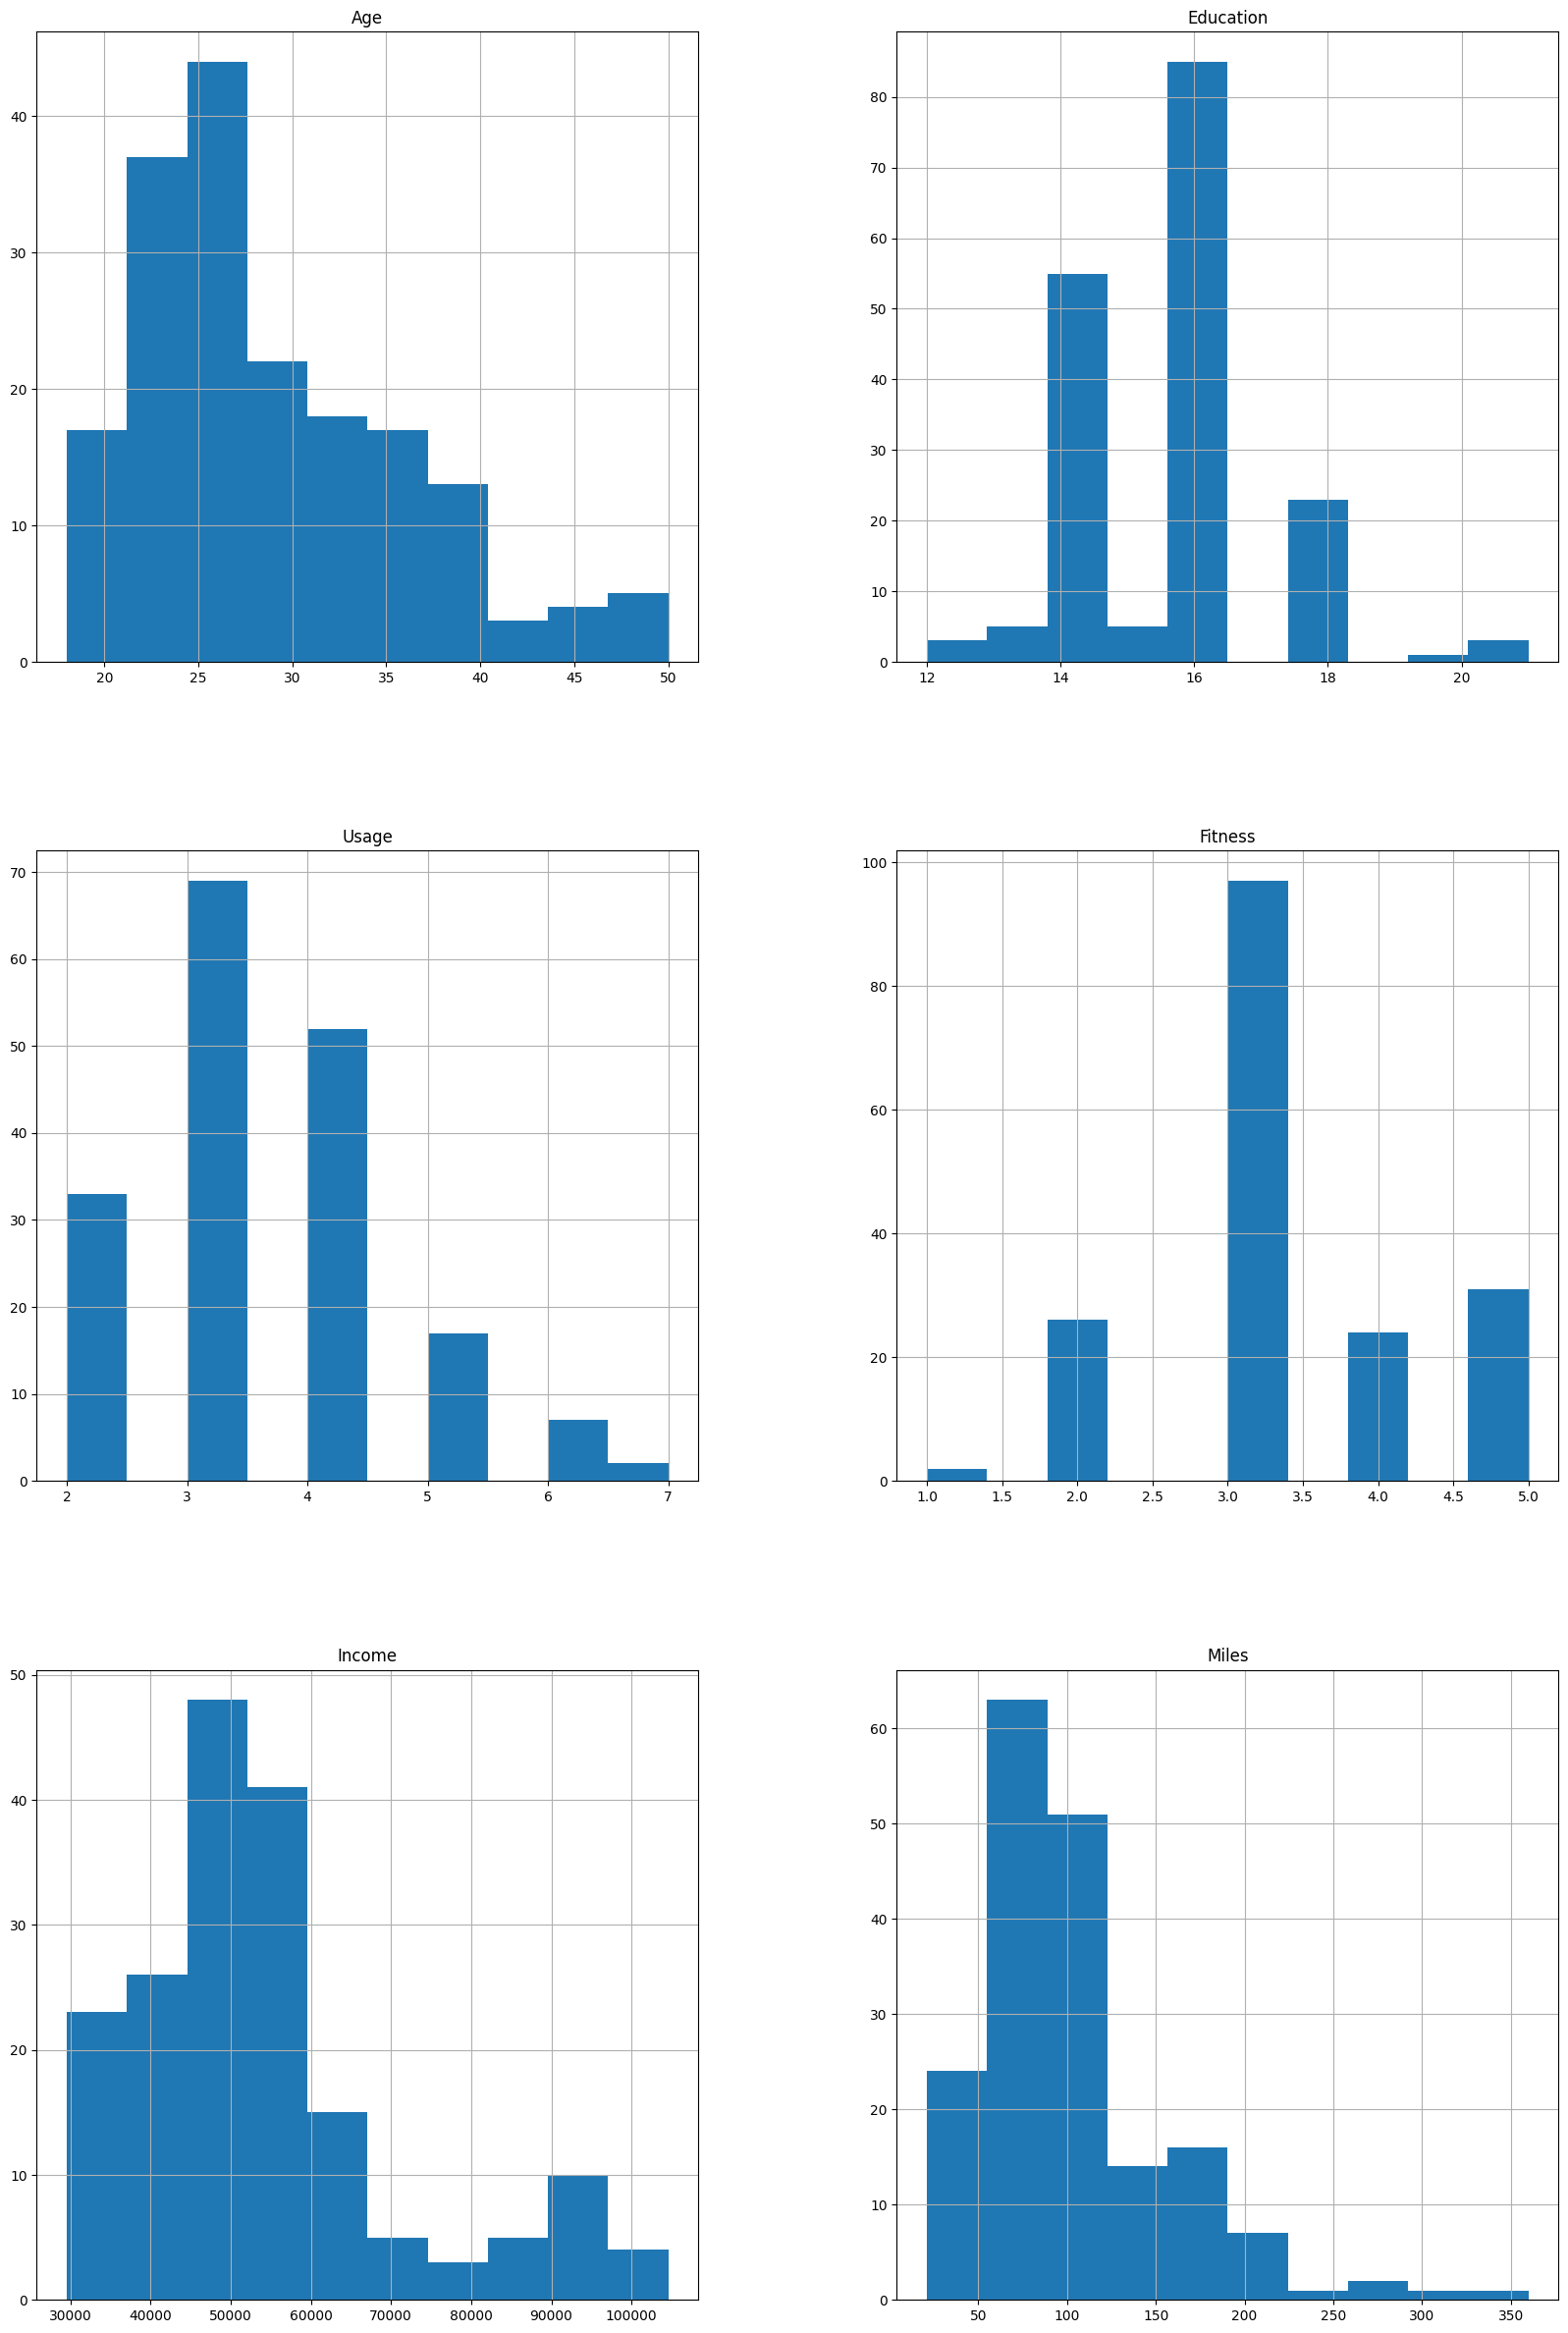

In [6]:
mydata.hist(figsize=(20,30))

<Axes: xlabel='Gender', ylabel='Age'>

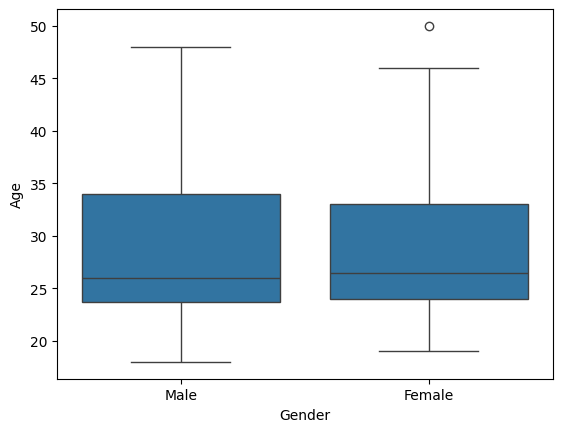

In [7]:
sns.boxplot(x="Gender", y="Age", data=mydata)

<Axes: xlabel='Product', ylabel='Age'>

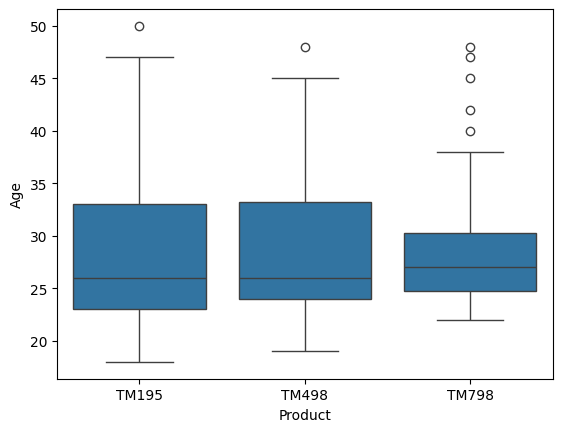

In [8]:
sns.boxplot(x="Product", y="Age", data=mydata)

In [9]:
pd.crosstab(mydata['Product'],mydata['Gender'] )

Gender,Female,Male
Product,,
TM195,40,40
TM498,29,31
TM798,7,33


In [10]:
pd.crosstab(mydata['Product'],mydata['MaritalStatus'] )

MaritalStatus,Partnered,Single
Product,,
TM195,48,32
TM498,36,24
TM798,23,17


<Axes: xlabel='Product', ylabel='count'>

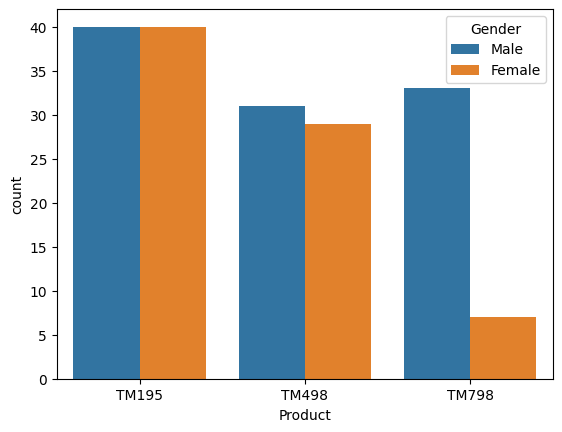

In [11]:
sns.countplot(x="Product", hue="Gender", data=mydata)

In [12]:
pd.pivot_table(mydata, index=['Product', 'Gender'],
                     columns=[ 'MaritalStatus'], aggfunc=len)

Age        Education          Fitness           Income  \
MaritalStatus  Partnered Single Partnered Single Partnered Single Partnered   
Product Gender                                                                
TM195   Female        27     13        27     13        27     13        27   
        Male          21     19        21     19        21     19        21   
TM498   Female        15     14        15     14        15     14        15   
        Male          21     10        21     10        21     10        21   
TM798   Female         4      3         4      3         4      3         4   
        Male          19     14        19     14        19     14        19   

                          Miles            Usage         
MaritalStatus  Single Partnered Single Partnered Single  
Product Gender                                           
TM195   Female     13        27     13        27     13  
        Male       19        21     19        21     19  
TM498   Female     14        15     14        15     14  
        Male       10        21     10        21     10  
TM798   Female      3         4      3         4      3  
        Male       14        19     14        19     14

In [13]:
pd.pivot_table(mydata, values='Income', index=['Product', 'Gender'],
                     columns=[ 'MaritalStatus'])

MaritalStatus      Partnered        Single
Product Gender                            
TM195   Female  46153.777778  45742.384615
        Male    50028.000000  43265.842105
TM498   Female  49724.800000  48920.357143
        Male    49378.285714  47071.800000
TM798   Female  84972.250000  58516.000000
        Male    81431.368421  68216.428571

#### pd.pivot_table(mydata,'Miles', index=['Product', 'Gender'],
                     columns=[ 'MaritalStatus'])

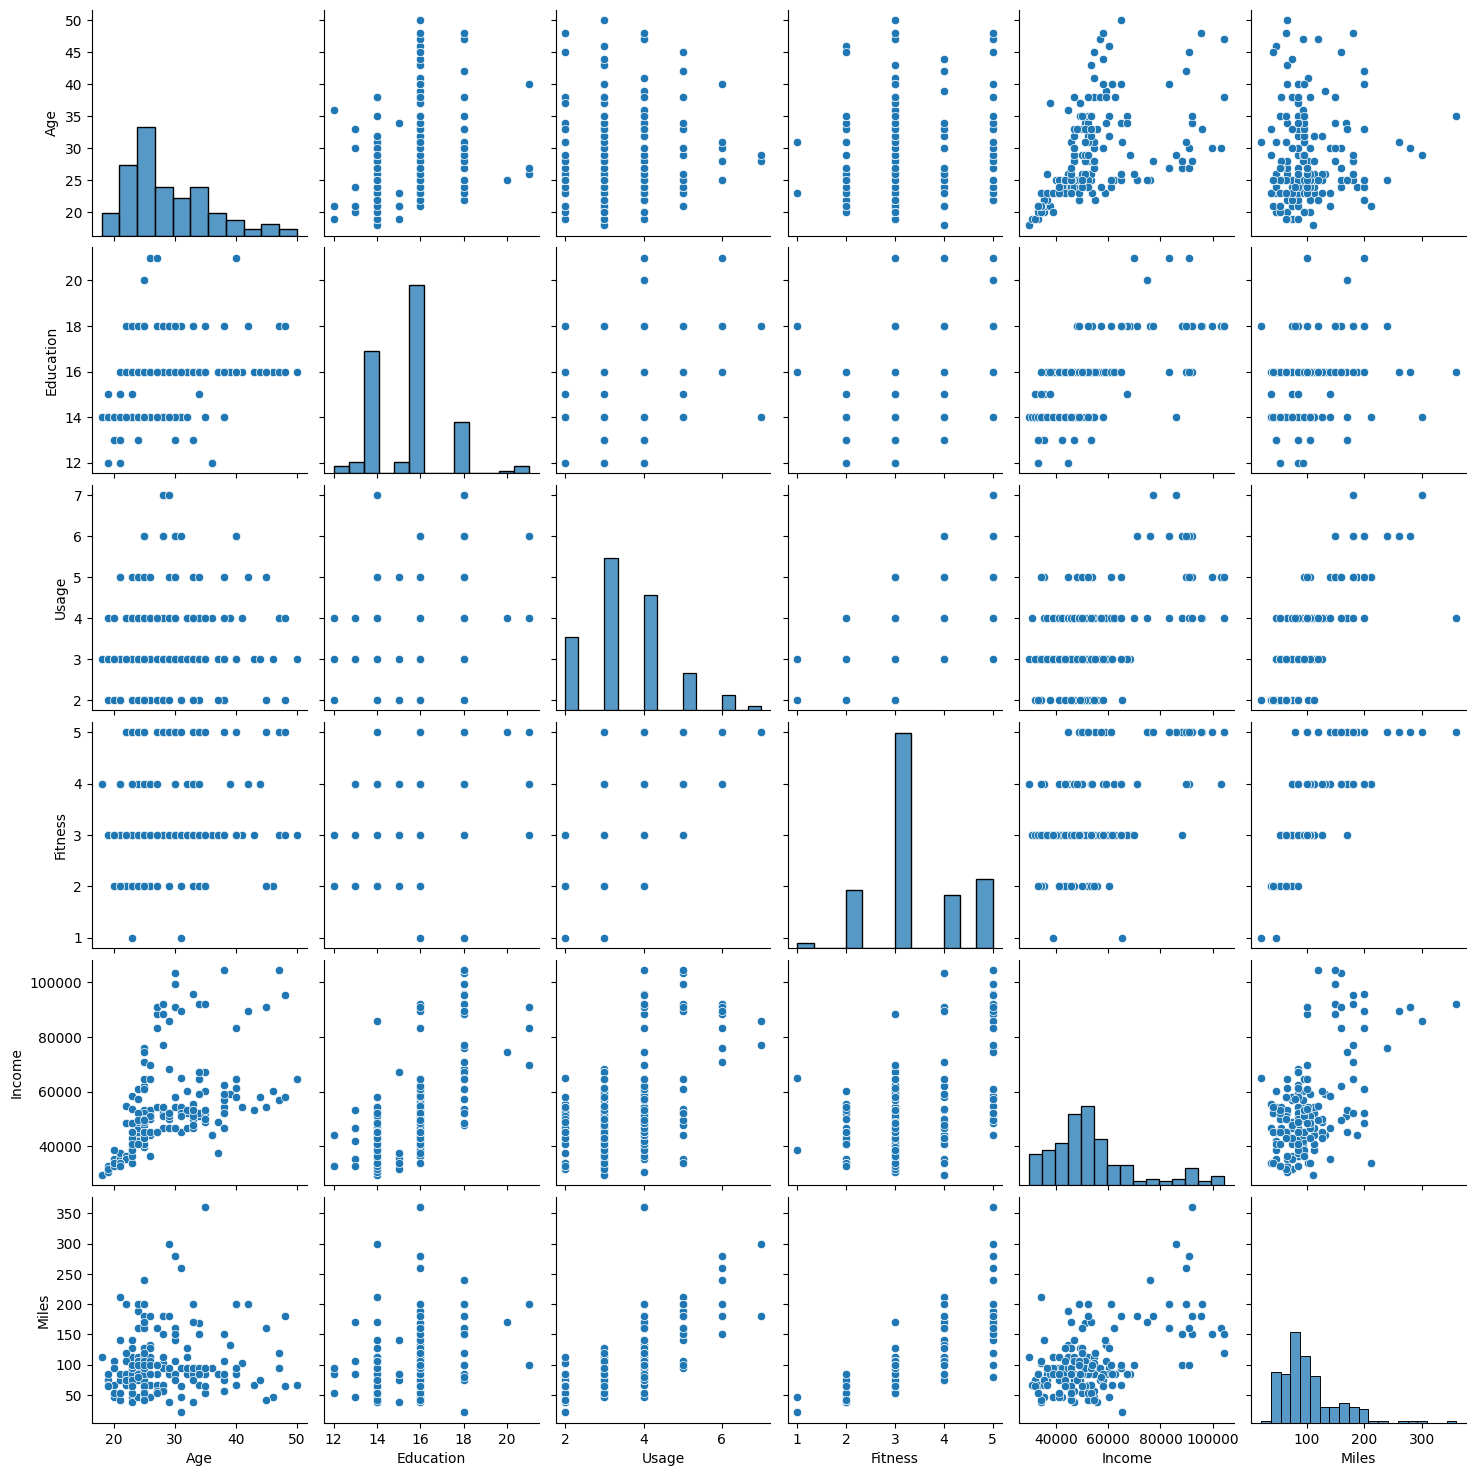

In [14]:
sns.pairplot(mydata)

In [15]:
mydata['Age'].std()

np.float64(6.943498135399795)

In [16]:
mydata['Age'].mean()

np.float64(28.788888888888888)

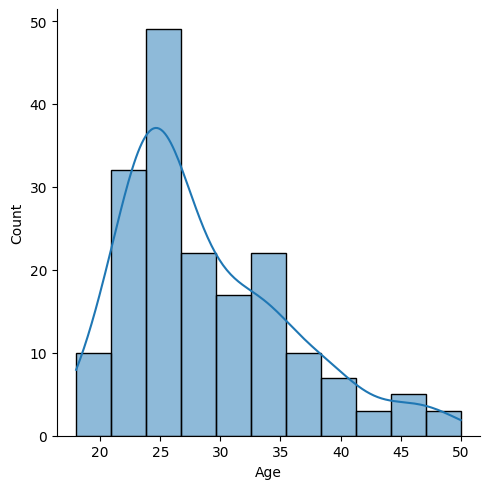

In [17]:
sns.displot(data=mydata, x='Age', kde=True)

array([<Axes: title={'center': 'Female'}>,
       <Axes: title={'center': 'Male'}>], dtype=object)

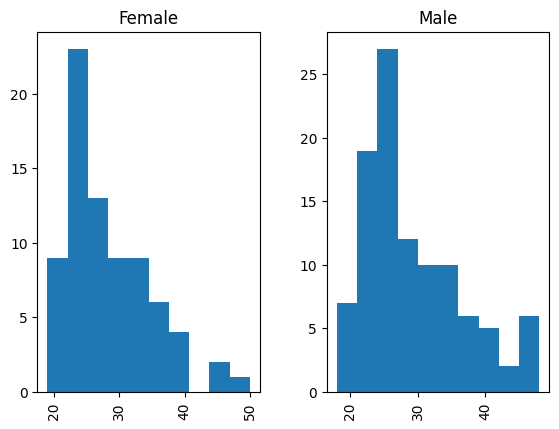

In [18]:
mydata.hist(by='Gender',column = 'Age')

array([<Axes: title={'center': 'Female'}>,
       <Axes: title={'center': 'Male'}>], dtype=object)

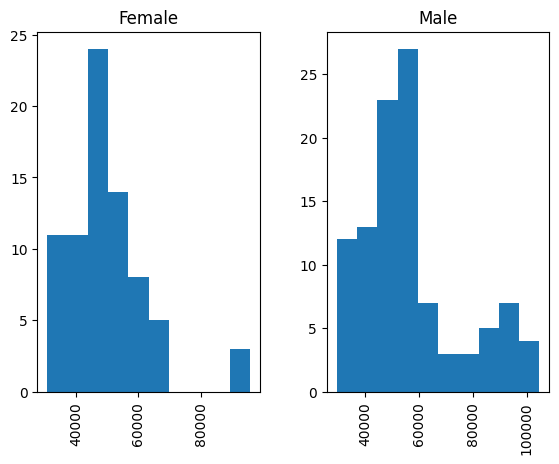

In [19]:
mydata.hist(by='Gender',column = 'Income')

array([<Axes: title={'center': 'Female'}>,
       <Axes: title={'center': 'Male'}>], dtype=object)

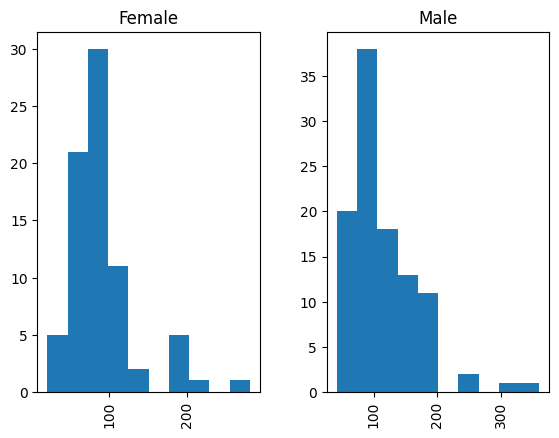

In [20]:
mydata.hist(by='Gender',column = 'Miles')

<Axes: xlabel='Miles', ylabel='Count'>

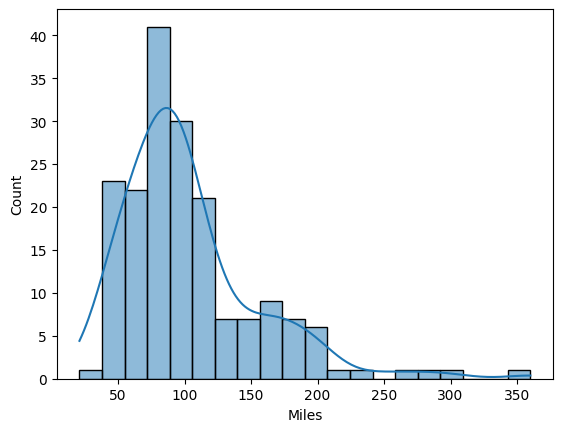

In [21]:
sns.histplot(data=mydata, x='Miles',kde=True)

array([[<Axes: title={'center': 'TM195'}>,
        <Axes: title={'center': 'TM498'}>],
       [<Axes: title={'center': 'TM798'}>, <Axes: >]], dtype=object)

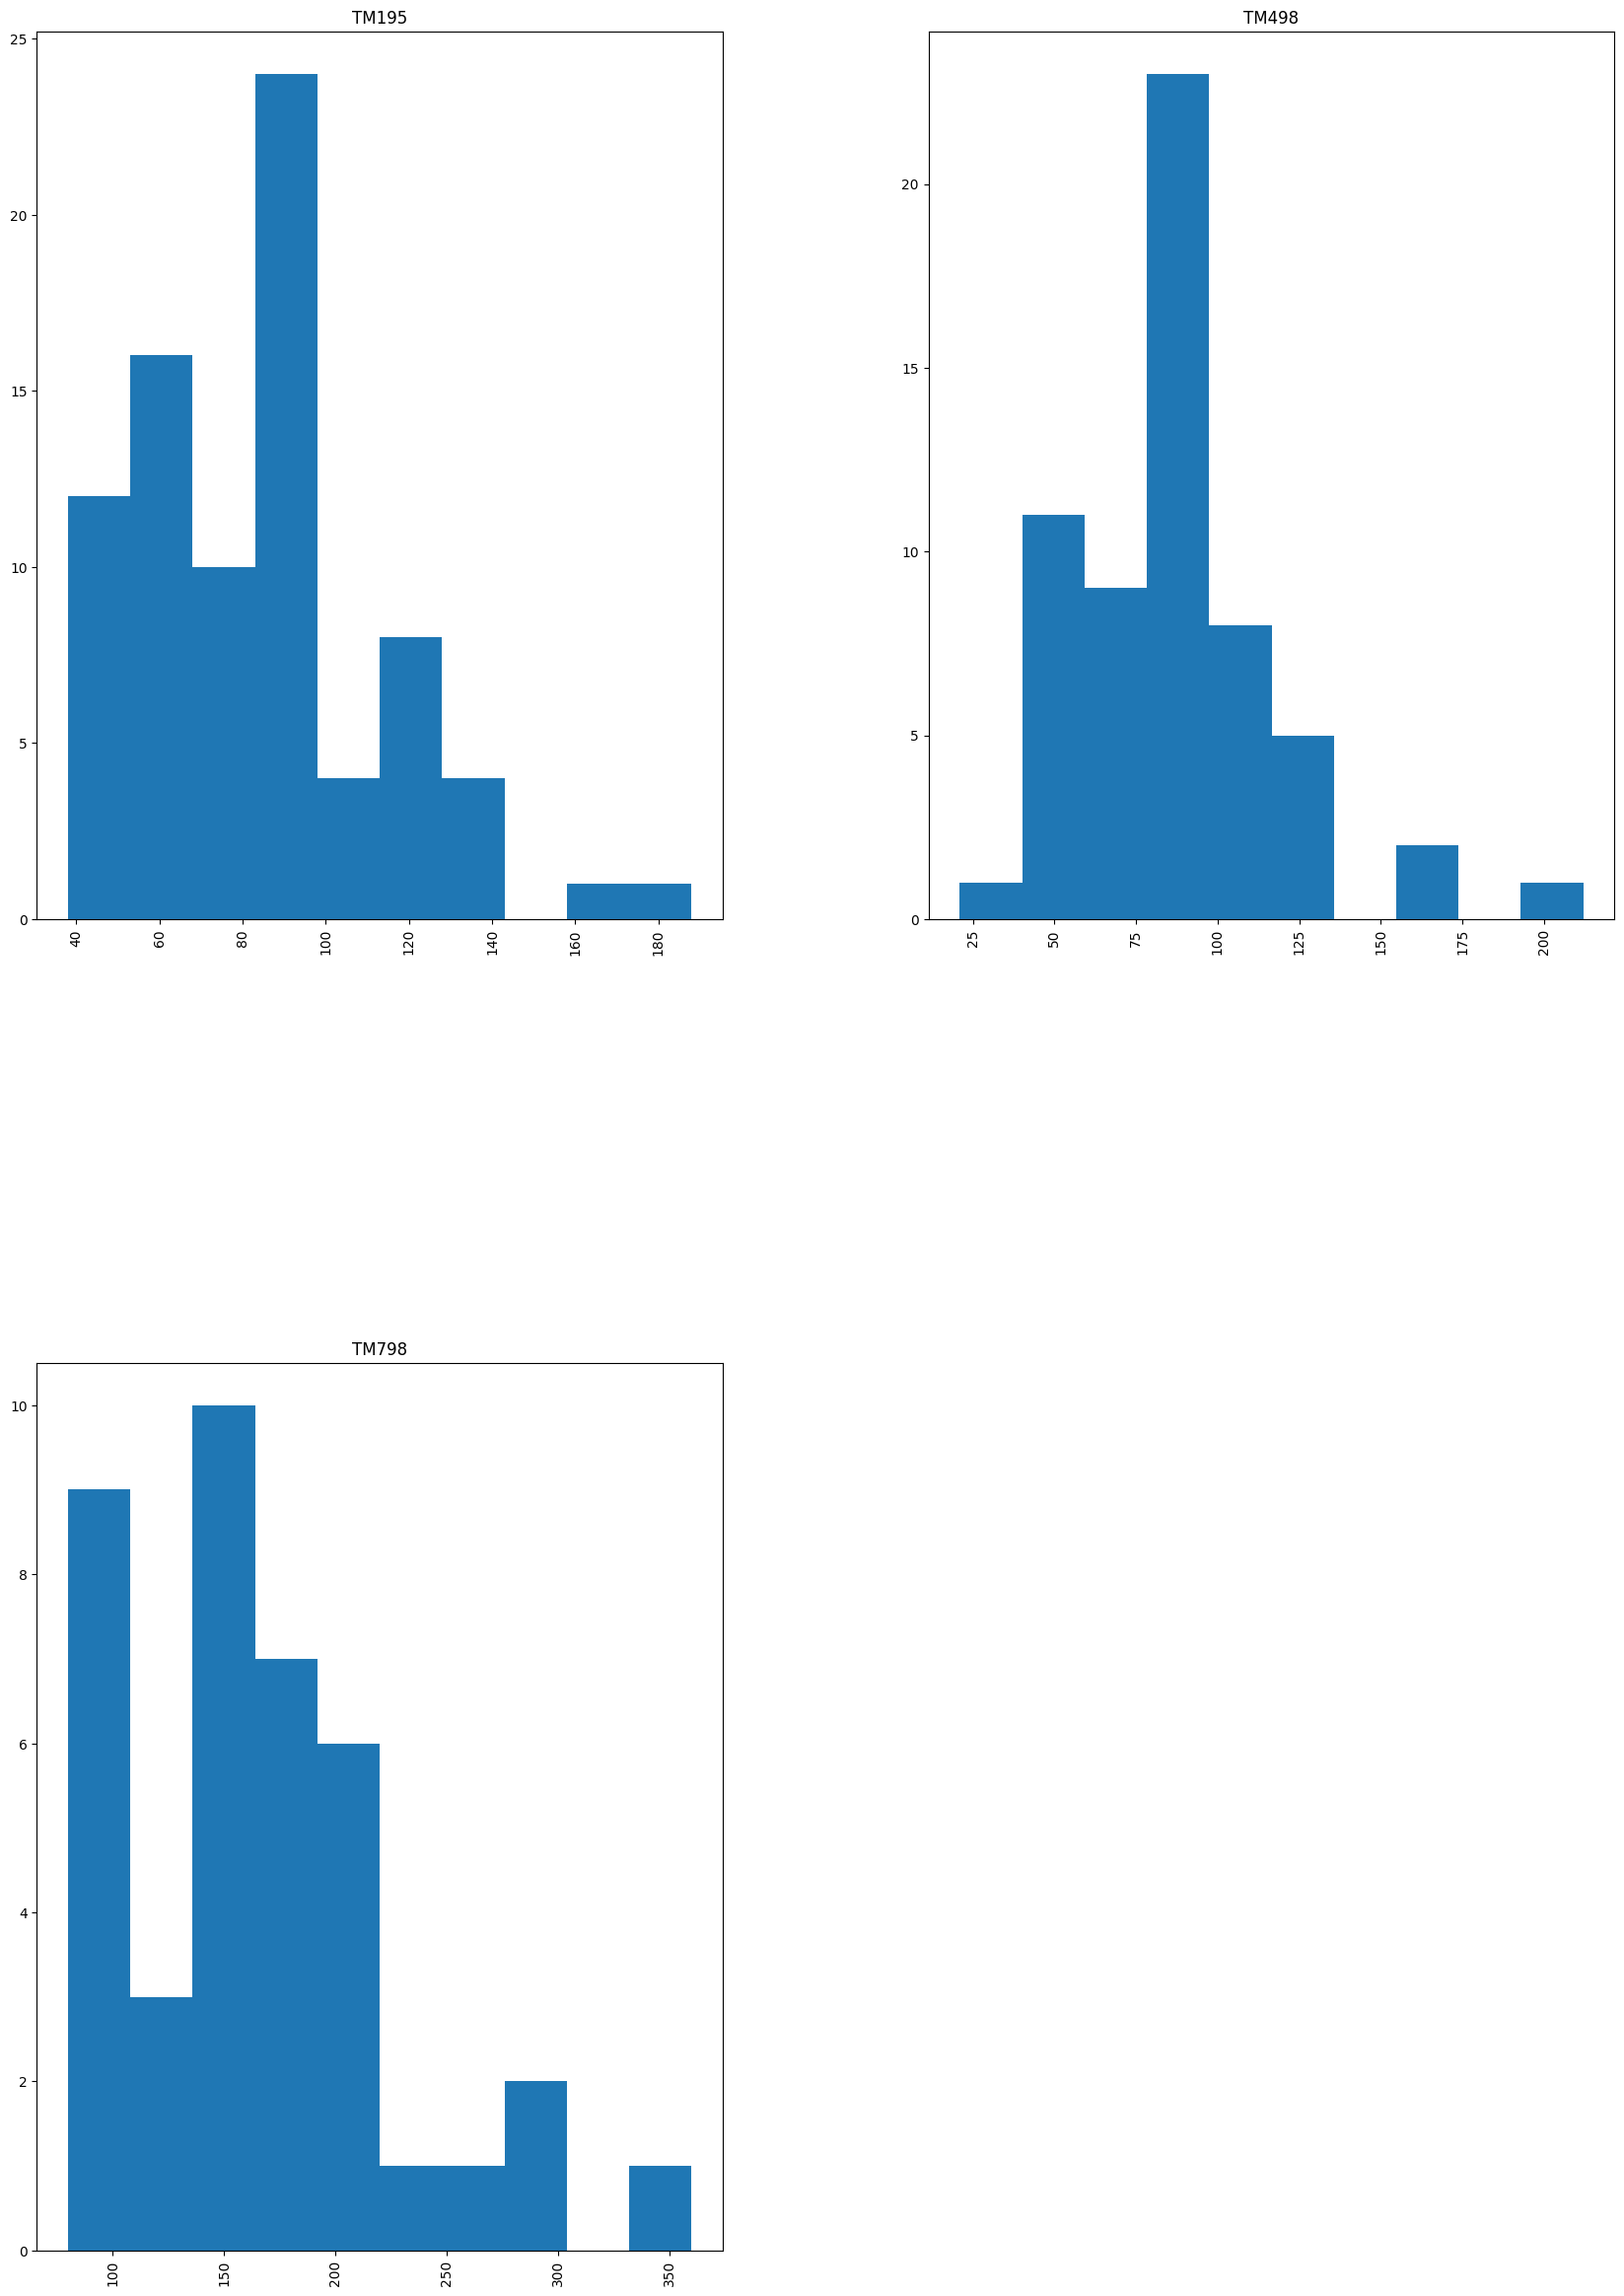

In [22]:
mydata.hist(by='Product',column = 'Miles', figsize=(20,30))

In [23]:
mydata

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,TM195,18,Male,14,Single,3,4,29562,112
1,TM195,19,Male,15,Single,2,3,31836,75
2,TM195,19,Female,14,Partnered,4,3,30699,66
3,TM195,19,Male,12,Single,3,3,32973,85
4,TM195,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,TM798,40,Male,21,Single,6,5,83416,200
176,TM798,42,Male,18,Single,5,4,89641,200
177,TM798,45,Male,16,Single,5,5,90886,160
178,TM798,47,Male,18,Partnered,4,5,104581,120


In [24]:
corr = mydata.corr(numeric_only=True)
corr

,Age,Education,Usage,Fitness,Income,Miles
Age,1.000000,0.280496,0.015064,0.061105,0.513414,0.036618
Education,0.280496,1.000000,0.395155,0.410581,0.625827,0.307284
Usage,0.015064,0.395155,1.000000,0.668606,0.519537,0.759130
Fitness,0.061105,0.410581,0.668606,1.000000,0.535005,0.785702
Income,0.513414,0.625827,0.519537,0.535005,1.000000,0.543473
Miles,0.036618,0.307284,0.759130,0.785702,0.543473,1.000000


<Axes: >

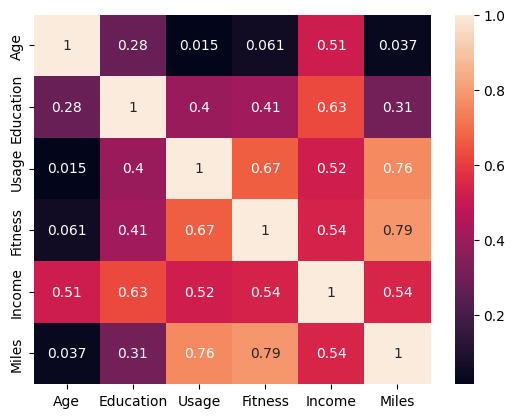

In [25]:
sns.heatmap(corr, annot=True)

#### Test simple linear regression for product recommendation

In [30]:
# We can consider a simple multiple linear regression to determine the average number of miles a customer will walk/run per week 
# based on two other variables: their expected weekly usage of the treadmill and their self-rated fitness level.
# We can use this prediction to determine which treadmill model is most popular based on their data.
regr = linear_model.LinearRegression()

y = mydata['Miles']
x = mydata[['Usage','Fitness']]

# Train the model using the training sets
regr.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [65]:
regr.coef_

array([20.21486334, 27.20649954])

In [66]:
regr.intercept_

np.float64(-56.742881784648645)

<Axes: xlabel='Product', ylabel='Miles'>

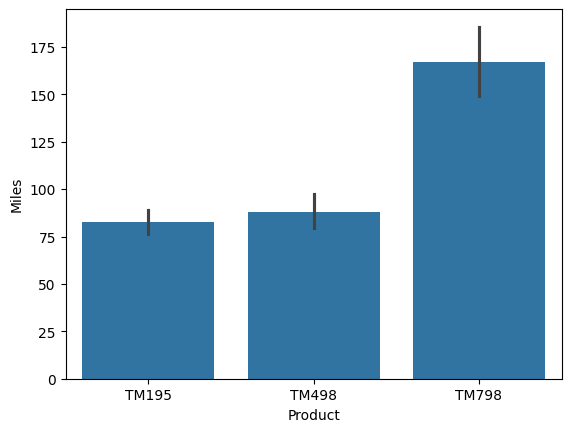

In [70]:
sns.barplot(data=mydata, x='Product', y='Miles')

<Axes: xlabel='Miles', ylabel='Count'>

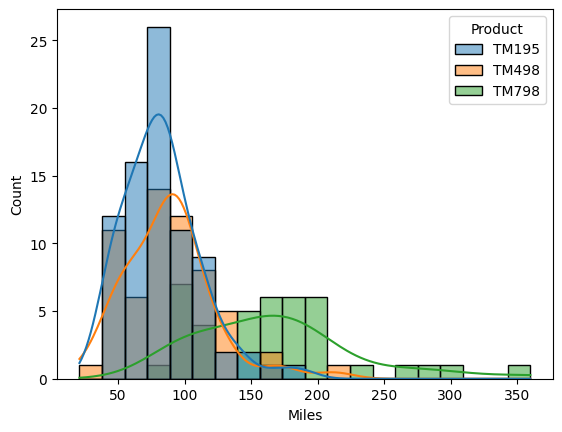

In [29]:
sns.histplot(data=mydata, x='Miles',hue='Product',kde=True)

In [27]:
average_miles_series = mydata.groupby('Product')['Miles'].mean()

In [28]:
average_miles_series

Product
TM195     82.787500
TM498     87.933333
TM798    166.900000
Name: Miles, dtype: float64

In [ ]:
# MilesPredicted = -56.74 + 20.21*Usage + 27.20*Fitness

In [74]:
def milespredicted(usage,fitness): 
    return regr.intercept_ + regr.coef_[0]*usage + regr.coef_[1]*fitness

In [75]:
milespredicted(3,4)

np.float64(112.72770638245585)

For a sample user, basing only on their planned usage and fitness level, CardioGood Fitness could recommend/upsell the TM798 which appears to be more catered to a wider-range of users or higher performance athletes, or the TM498 for cost-savings to the user based on the average miles per treadmill. Depending on other factors, i.e. inventory availability, there may be incentive to sell one over the other.

#### Create customer profiling for each treadmill product

In [67]:
def create_customer_profiles(data):
    """Create simple customer profiles for each product"""
    profiles = []
    
    for product in data['Product'].unique():
        product_data = data[data['Product'] == product]
        
        profile = {
            'Product': product,
            'Total_Customers': len(product_data),
            'Age_Range': f"{product_data['Age'].min()}-{product_data['Age'].max()} years",
            'Age_Average': f"{product_data['Age'].mean():.0f} years",
            'Income_Range': f"${product_data['Income'].min():,}-${product_data['Income'].max():,}",
            'Income_Average': f"${product_data['Income'].mean():,.0f}",
            'Usage_Range': f"{product_data['Usage'].min()}-{product_data['Usage'].max()} times/week",
            'Usage_Average': f"{product_data['Usage'].mean():.1f} times/week",
            'Fitness_Range': f"{product_data['Fitness'].min()}-{product_data['Fitness'].max()} out of 5",
            'Fitness_Average': f"{product_data['Fitness'].mean():.1f} out of 5",
            'Miles_Range': f"{product_data['Miles'].min():.0f}-{product_data['Miles'].max():.0f} miles/week",
            'Miles_Average': f"{product_data['Miles'].mean():.0f} miles/week",
            'Education_Range': f"{product_data['Education'].min()}-{product_data['Education'].max()} years",
            'Education_Average': f"{product_data['Education'].mean():.1f} years",
            'Most_Common_Gender': product_data['Gender'].mode().iloc[0],
            'Gender_Split': f"{(product_data['Gender'] == 'Male').mean()*100:.0f}% Male, {(product_data['Gender'] == 'Female').mean()*100:.0f}% Female",
            'Most_Common_Marital': product_data['MaritalStatus'].mode().iloc[0],
            'Marital_Split': f"{(product_data['MaritalStatus'] == 'Single').mean()*100:.0f}% Single, {(product_data['MaritalStatus'] == 'Partnered').mean()*100:.0f}% Partnered"
        }
        
        profiles.append(profile)
    
    return pd.DataFrame(profiles)

In [70]:
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
profiles = create_customer_profiles(mydata)
profiles

,Product,Total_Customers,Age_Range,Age_Average,Income_Range,Income_Average,Usage_Range,Usage_Average,Fitness_Range,Fitness_Average,Miles_Range,Miles_Average,Education_Range,Education_Average,Most_Common_Gender,Gender_Split,Most_Common_Marital,Marital_Split
0,TM195,80,18-50 years,29 years,"$29,562-$68,220","$46,418",2-5 times/week,3.1 times/week,1-5 out of 5,3.0 out of 5,38-188 miles/week,83 miles/week,12-18 years,15.0 years,Female,"50% Male, 50% Female",Partnered,"40% Single, 60% Partnered"
1,TM498,60,19-48 years,29 years,"$31,836-$67,083","$48,974",2-5 times/week,3.1 times/week,1-4 out of 5,2.9 out of 5,21-212 miles/week,88 miles/week,12-18 years,15.1 years,Male,"52% Male, 48% Female",Partnered,"40% Single, 60% Partnered"
2,TM798,40,22-48 years,29 years,"$48,556-$104,581","$75,442",3-7 times/week,4.8 times/week,3-5 out of 5,4.6 out of 5,80-360 miles/week,167 miles/week,14-21 years,17.3 years,Male,"82% Male, 18% Female",Partnered,"42% Single, 57% Partnered"


Based on this customer profile summary, the product marketing team can consider to define or refine the customer profile for each othese treadmill products. For example:

1. TM195: Market to couples/families as an entry-level option
2. TM498: Target middle-income households looking for reliable equipment  
3. TM798: Focus on male fitness enthusiasts with higher incomes and education

#### Create enhanced classification model to determine best treadmill product for an individual

In [73]:
def model_preparation(data):
    """Prepare data for machine learning model"""
    # Create a copy of the data
    model_data = data.copy()
    
    # Encode categorical variables
    le_gender = LabelEncoder()
    le_marital = LabelEncoder()
    
    model_data['Gender_encoded'] = le_gender.fit_transform(model_data['Gender'])
    model_data['MaritalStatus_encoded'] = le_marital.fit_transform(model_data['MaritalStatus'])
    
    # Features for prediction (everything except Product and original categorical columns)
    feature_columns = ['Age', 'Gender_encoded', 'Education', 'MaritalStatus_encoded', 
                      'Usage', 'Fitness', 'Income', 'Miles']
    
    X = model_data[feature_columns]
    y = model_data['Product']
    
    return X, y, le_gender, le_marital, feature_columns


In [74]:
X, y, le_gender, le_marital, feature_columns = model_preparation(mydata)

In [82]:
def algo_select(X, y):
    """Try different algorithms to find the best one"""
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Scale features for algorithms that need it
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Define models
    models = {
        'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42),
        'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42, C=10, gamma='scale'),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, max_iter=1000)
    }
    
    results = {}
    best_model = None
    best_score = 0
    best_name = ""
    best_scaler = None
    
    print("Comparing Different Algorithms:")
    print("=" * 50)
    
    for name, model in models.items():
        # Use scaled data for SVM and Neural Network
        if name in ['SVM (RBF)', 'Neural Network']:
            X_train_use = X_train_scaled
            X_test_use = X_test_scaled
            use_scaler = True
        else:
            X_train_use = X_train
            X_test_use = X_test
            use_scaler = False
        
        # Train model
        model.fit(X_train_use, y_train)
        
        # Test accuracy
        y_pred = model.predict(X_test_use)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Cross-validation
        if use_scaler:
            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        else:
            cv_scores = cross_val_score(model, X_train, y_train, cv=5)
        
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'use_scaler': use_scaler
        }
        
        print(f"{name}:")
        print(f"  Test Accuracy: {accuracy:.2%}")
        print(f"  CV Score: {cv_scores.mean():.2%} (±{cv_scores.std() * 2:.2%})")
        
        if accuracy > best_score:
            best_score = accuracy
            best_model = model
            best_name = name
            best_scaler = scaler if use_scaler else None
        
        print()
    
    print(f"Best Model: {best_name} with {best_score:.2%} accuracy")
    return results, best_model, best_name, best_scaler, X_test, y_test

In [83]:
results, best_model, best_name, best_scaler, X_test, y_test = algo_select(X, y)

Comparing Different Algorithms:
Random Forest:
  Test Accuracy: 69.44%
  CV Score: 67.46% (±17.89%)

Gradient Boosting:
  Test Accuracy: 75.00%
  CV Score: 81.97% (±16.46%)

SVM (RBF):
  Test Accuracy: 55.56%
  CV Score: 59.16% (±21.45%)

Neural Network:
  Test Accuracy: 63.89%
  CV Score: 62.61% (±21.09%)

Best Model: Gradient Boosting with 75.00% accuracy


In [84]:
def create_ensemble(X, y):
    """Create ensemble of the best performing models"""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Best performing models
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
    svm = SVC(kernel='rbf', probability=True, random_state=42, C=10, gamma='scale')
    
    # Train individual models
    rf.fit(X_train, y_train)
    gb.fit(X_train, y_train) 
    svm.fit(X_train_scaled, y_train)
    
    # Create ensemble voting classifier
    # We'll use a custom approach since models use different scaling
    def ensemble_predict(X_input):
        # Get predictions from each model
        rf_pred = rf.predict_proba(X_input)
        gb_pred = gb.predict_proba(X_input) 
        svm_pred = svm.predict_proba(scaler.transform(X_input))
        
        # Average the probabilities
        avg_probs = (rf_pred + gb_pred + svm_pred) / 3
        
        # Return class with highest average probability
        return rf.classes_[np.argmax(avg_probs, axis=1)]
    
    def ensemble_predict_proba(X_input):
        rf_pred = rf.predict_proba(X_input)
        gb_pred = gb.predict_proba(X_input)
        svm_pred = svm.predict_proba(scaler.transform(X_input))
        return (rf_pred + gb_pred + svm_pred) / 3
    
    # Test ensemble
    ensemble_pred = ensemble_predict(X_test)
    ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
    
    print(f"Ensemble Model Accuracy: {ensemble_accuracy:.2%}")
    
    # Create a simple ensemble class
    class SimpleEnsemble:
        def __init__(self, rf_model, gb_model, svm_model, scaler):
            self.rf = rf_model
            self.gb = gb_model
            self.svm = svm_model
            self.scaler = scaler
            self.classes_ = rf_model.classes_
        
        def predict(self, X):
            rf_pred = self.rf.predict_proba(X)
            gb_pred = self.gb.predict_proba(X)
            svm_pred = self.svm.predict_proba(self.scaler.transform(X))
            avg_probs = (rf_pred + gb_pred + svm_pred) / 3
            return self.classes_[np.argmax(avg_probs, axis=1)]
        
        def predict_proba(self, X):
            rf_pred = self.rf.predict_proba(X)
            gb_pred = self.gb.predict_proba(X)
            svm_pred = self.svm.predict_proba(self.scaler.transform(X))
            return (rf_pred + gb_pred + svm_pred) / 3
    
    ensemble_model = SimpleEnsemble(rf, gb, svm, scaler)
    
    return ensemble_model, ensemble_accuracy

In [85]:
ensemble_model, ensemble_accuracy = create_ensemble(X, y)

Ensemble Model Accuracy: 72.22%


In [87]:
# Choose final model
best_single_accuracy = max([r['accuracy'] for r in results.values()])
print(best_single_accuracy)

0.75


In [91]:
final_model, final_accuracy, model_name = (ensemble_model, ensemble_accuracy, "Ensemble") if ensemble_accuracy > best_single_accuracy else (best_model, best_single_accuracy, best_name)

In [92]:
print(f"\nFinal Model: {model_name} ({final_accuracy:.2%} accuracy)")


Final Model: Gradient Boosting (75.00% accuracy)


In [90]:
# Show feature importance for tree-based models
if hasattr(final_model, 'feature_importances_') or hasattr(final_model, 'rf'):
    print(f"\nFeature Importance:")
    if hasattr(final_model, 'rf'):  # Ensemble
        importance = final_model.rf.feature_importances_
    else:
        importance = final_model.feature_importances_
        
    for feature, imp in zip(feature_columns, importance):
        print(f"  {feature}: {imp:.3f}") 


Feature Importance:
  Age: 0.094
  Gender_encoded: 0.005
  Education: 0.051
  MaritalStatus_encoded: 0.016
  Usage: 0.033
  Fitness: 0.225
  Income: 0.179
  Miles: 0.398


In [93]:
def predict_treadmill(model, le_gender, le_marital, feature_columns, customer_data, scaler=None):
    """Make prediction for a new customer"""
    # Prepare input
    input_data = customer_data.copy()
    
    # Encode categoricals
    input_data['Gender_encoded'] = le_gender.transform([input_data['Gender']])[0]
    input_data['MaritalStatus_encoded'] = le_marital.transform([input_data['MaritalStatus']])[0]
    
    # Create feature vector
    feature_vector = np.array([input_data[col] for col in feature_columns]).reshape(1, -1)
    
    # Make prediction
    prediction = model.predict(feature_vector)[0]
    probabilities = model.predict_proba(feature_vector)[0]
    
    # Format results
    results = []
    for i, prob in enumerate(probabilities):
        results.append({
            'Product': model.classes_[i],
            'Confidence': prob * 100
        })
    
    results.sort(key=lambda x: x['Confidence'], reverse=True)
    
    return prediction, results

In [94]:
# Test customer 1: College student and budget-conscious
customer1 = {
    'Age': 25, 'Gender': 'Female', 'Education': 14, 'MaritalStatus': 'Single',
    'Usage': 2, 'Fitness': 2, 'Income': 35000, 'Miles': 60
}

In [96]:
pred1, results1 = predict_treadmill(final_model, le_gender, le_marital, feature_columns, customer1)

In [98]:
for result in results1:
    print(f"    {result['Product']}: {result['Confidence']:.1f}%")

    TM195: 100.0%
    TM498: 0.0%
    TM798: 0.0%


In [99]:
 # Test customer 2: Active male athlete
customer2 = {
    'Age': 35, 'Gender': 'Male', 'Education': 18, 'MaritalStatus': 'Partnered',
    'Usage': 5, 'Fitness': 5, 'Income': 85000, 'Miles': 200
}

In [100]:
pred2, results2 = predict_treadmill(final_model, le_gender, le_marital, feature_columns, customer2)

In [101]:
for result in results2:
    print(f"    {result['Product']}: {result['Confidence']:.1f}%")

    TM798: 100.0%
    TM195: 0.0%
    TM498: 0.0%


The best model is able to predict with 75% for an individual on which treadmill product is most suitable for them.

In [103]:
# Save model
joblib.dump(final_model, 'best_treadmill_model.pkl')
joblib.dump(le_gender, 'gender_encoder.pkl')
joblib.dump(le_marital, 'marital_encoder.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

['feature_columns.pkl']